Machine Learning - Loan Approval Prediction
**Full Pipeline: Preprocessing → EDA → Modeling → Evaluation**

Dataset: [Loan Approval Prediction Dataset](https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset)

## 1. Import Libraries

In [1]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)


## 2. Load Dataset

In [2]:
path = kagglehub.dataset_download("architsharma01/loan-approval-prediction-dataset")
print("Path:", path)
print("Files:", os.listdir(path))

100%|██████████| 80.6k/80.6k [00:00<00:00, 41.9MB/s]

Extracting files...
Path: /root/.cache/kagglehub/datasets/architsharma01/loan-approval-prediction-dataset/versions/1
Files: ['loan_approval_dataset.csv']


In [3]:
df = pd.read_csv(path + "/loan_approval_dataset.csv")

df.columns = df.columns.str.strip()
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

print(f"Shape: {df.shape}")
df.head(10)

Shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


## 3. Exploratory Data Analysis (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [5]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [6]:
df.describe(include='object')

,education,self_employed,loan_status
count,4269,4269,4269
unique,2,2,2
top,Graduate,Yes,Approved
freq,2144,2150,2656


 Efor education & self_employed, we will use OHE encoding

In [7]:
# Target Distribution
print(df['loan_status'].value_counts(normalize=True) * 100)

loan_status
Approved   62.22
Rejected   37.78
Name: proportion, dtype: float64


##  4. Missing Value Check & Imputation

In [8]:
df.isnull().sum()


,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


No need to impute

## 5. Outlier Detection & Visualization

In [9]:
print("IQR-BASED OUTLIER DETECTION")

outlier_summary = {}
for col in df.select_dtypes(include=['number']).columns.tolist():
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    outlier_summary[col] = {'Lower Bound': lower, 'Upper Bound': upper, 'Outliers': n_out, 'Pct (%)': pct}
    print(f"{col:35s} → {n_out:4d} outliers ({pct:.1f}%)")

outlier_df = pd.DataFrame(outlier_summary).T

IQR-BASED OUTLIER DETECTION
loan_id                             →    0 outliers (0.0%)
no_of_dependents                    →    0 outliers (0.0%)
income_annum                        →    0 outliers (0.0%)
loan_amount                         →    0 outliers (0.0%)
loan_term                           →    0 outliers (0.0%)
cibil_score                         →    0 outliers (0.0%)
residential_assets_value            →   52 outliers (1.2%)
commercial_assets_value             →   37 outliers (0.9%)
luxury_assets_value                 →    0 outliers (0.0%)
bank_asset_value                    →    5 outliers (0.1%)


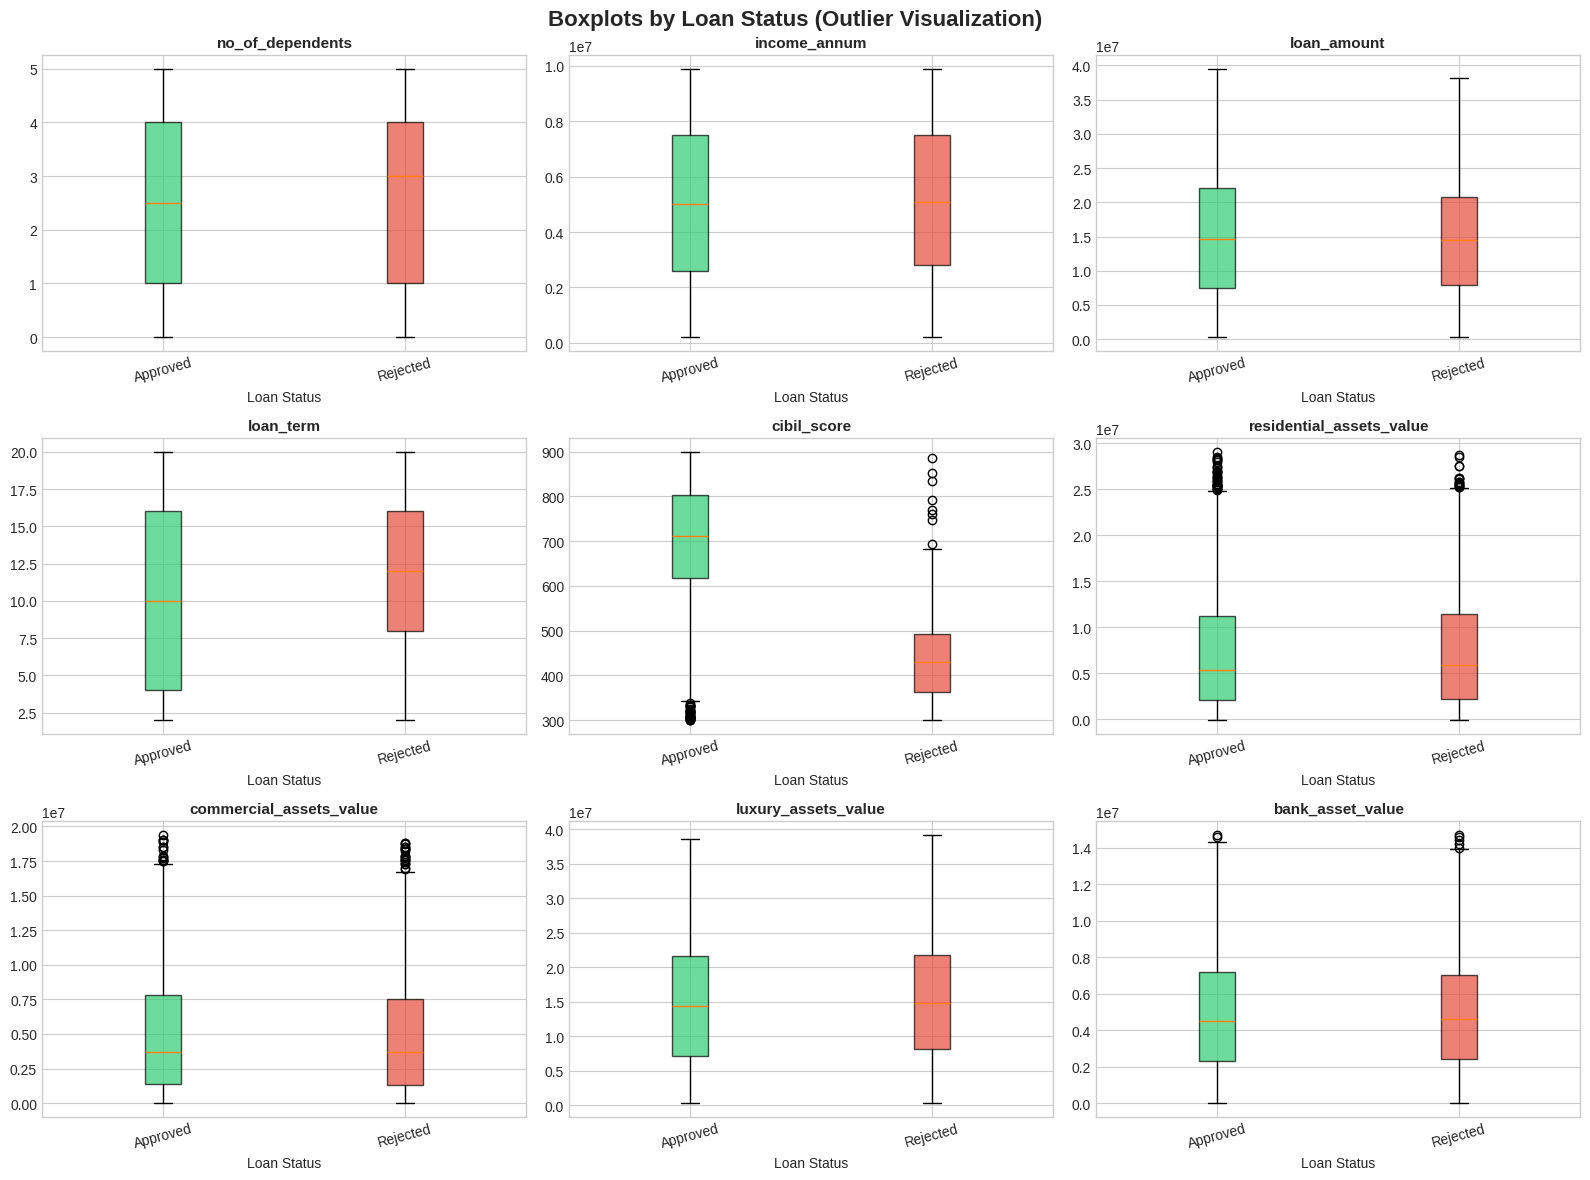

In [10]:
# Boxplots for each numerical feature
numerical_features = df.select_dtypes(include=['number']).columns.drop('loan_id').tolist()
n = len(numerical_features)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    data = [df[df['loan_status'] == status][col].dropna() for status in df['loan_status'].unique()]
    bp = axes[i].boxplot(data, patch_artist=True, labels=df['loan_status'].unique())
    colors_bp = ['#2ecc71', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Loan Status')
    axes[i].tick_params(axis='x', rotation=15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots by Loan Status (Outlier Visualization)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

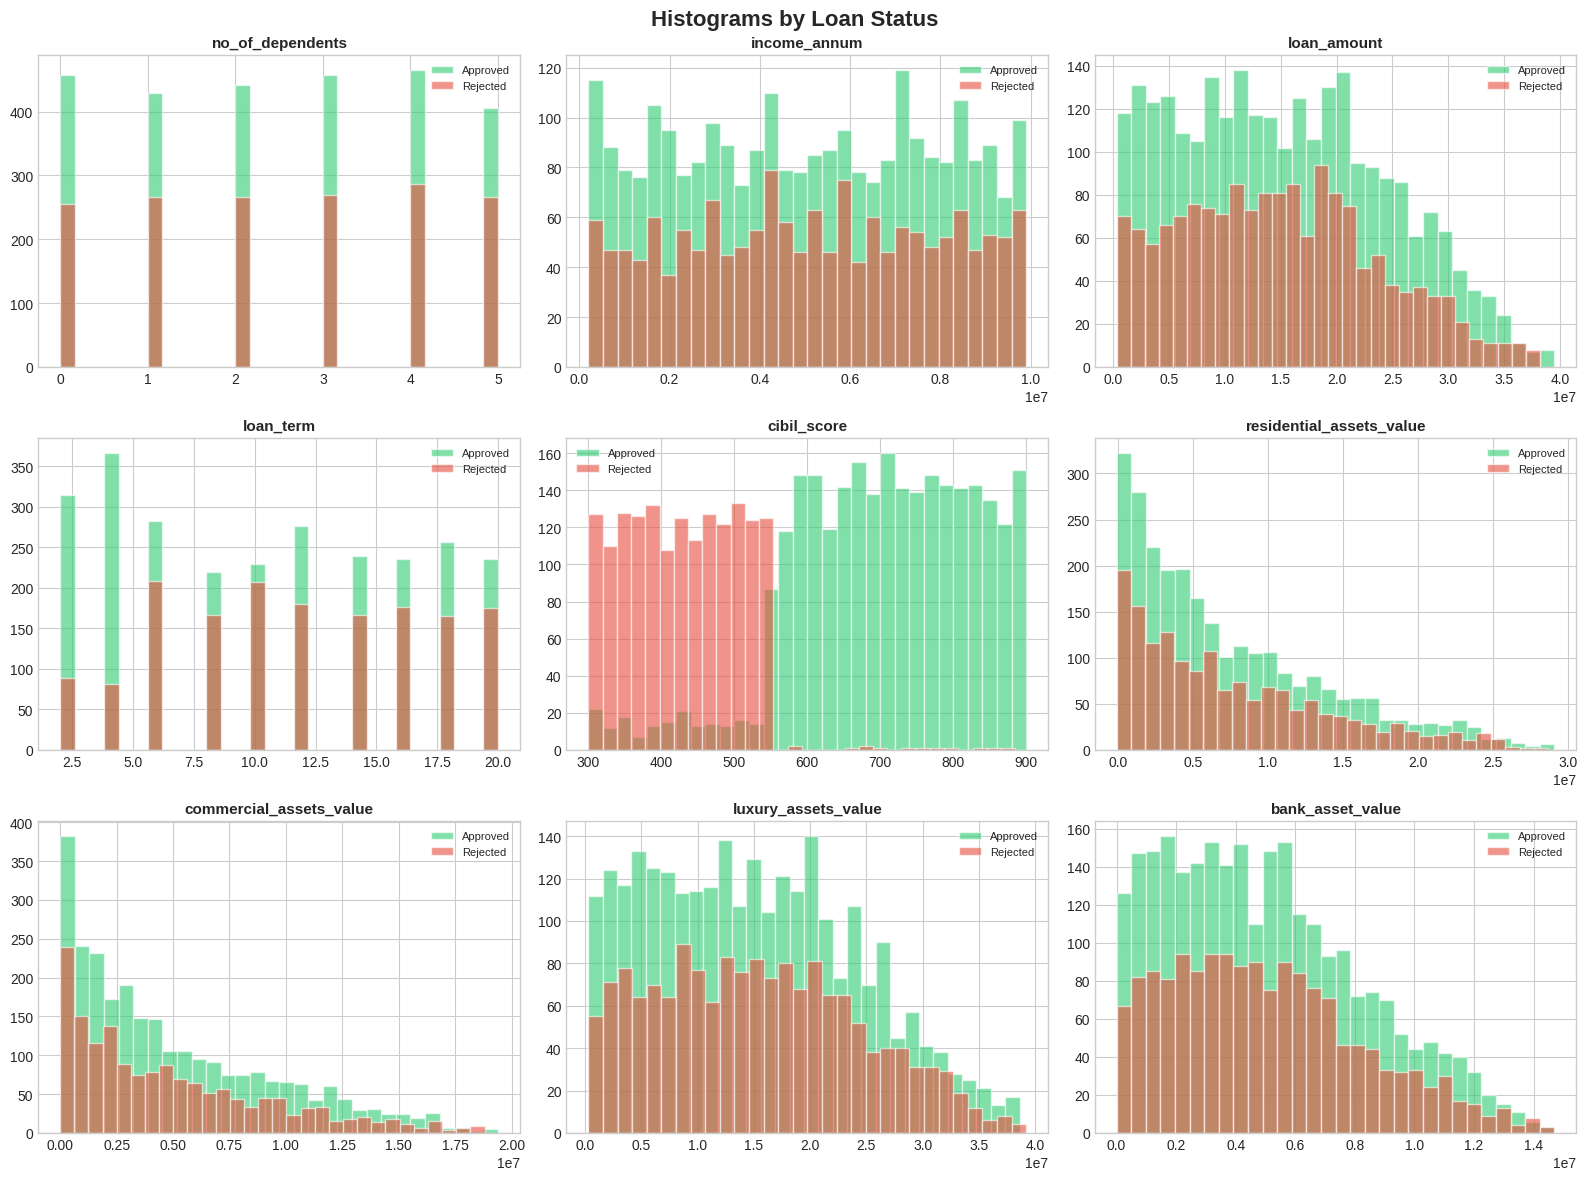

In [11]:
# Histogram Distribution
numerical_features = df.select_dtypes(include=['number']).columns.drop('loan_id').tolist()
n = len(numerical_features)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    for status, color in zip(df['loan_status'].unique(), ['#2ecc71', '#e74c3c']):
        subset = df[df['loan_status'] == status][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=status, edgecolor='white')
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)


plt.suptitle('Histograms by Loan Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

### a.Correlation for each fitur

NUMERICAL CORRELATION (Pearson)


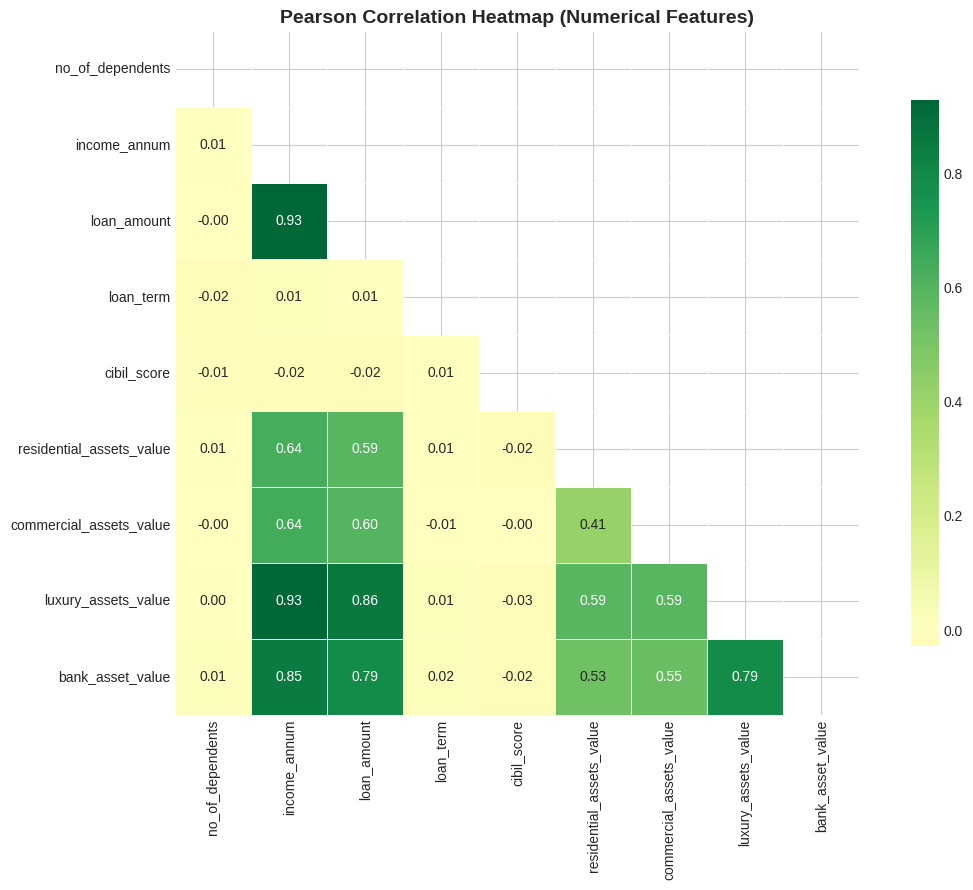

In [12]:
# ---- 6a. Numerical Correlation (Pearson) ----
print("=" * 60)
print("NUMERICAL CORRELATION (Pearson)")
print("=" * 60)

numerical_features = df.select_dtypes(include=['number']).columns.drop('loan_id').tolist()
corr_matrix = df[numerical_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Pearson Correlation Heatmap (Numerical Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



In [13]:
df.select_dtypes(include = 'number').corr()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
loan_id,1.00,0.01,0.01,0.01,0.01,0.02,0.02,0.02,-0.00,0.01
no_of_dependents,0.01,1.00,0.01,-0.00,-0.02,-0.01,0.01,-0.00,0.00,0.01
income_annum,0.01,0.01,1.00,0.93,0.01,-0.02,0.64,0.64,0.93,0.85
loan_amount,0.01,-0.00,0.93,1.00,0.01,-0.02,0.59,0.60,0.86,0.79
loan_term,0.01,-0.02,0.01,0.01,1.00,0.01,0.01,-0.01,0.01,0.02
cibil_score,0.02,-0.01,-0.02,-0.02,0.01,1.00,-0.02,-0.00,-0.03,-0.02
residential_assets_value,0.02,0.01,0.64,0.59,0.01,-0.02,1.00,0.41,0.59,0.53
commercial_assets_value,0.02,-0.00,0.64,0.60,-0.01,-0.00,0.41,1.00,0.59,0.55
luxury_assets_value,-0.00,0.00,0.93,0.86,0.01,-0.03,0.59,0.59,1.00,0.79
bank_asset_value,0.01,0.01,0.85,0.79,0.02,-0.02,0.53,0.55,0.79,1.00


- assets (income_annum, luxury_assets_value, bank_asset_value) vs loan_amount: high corr -> aset yg tinggi berfungsi sbg jaminan yg kuat
- income_annum vs luxury_assets_value, bank_asset_value: high corr -> variable kekayaann (wealth) & pendapatan (income) searah -> bantu model lebih stabil

### b. Correlation for target vs fitur

In [15]:
df_model = df.drop(columns=['loan_id'])
X = df_model.drop(columns=['loan_status'])
y = df_model['loan_status'].map({'Approved': 1, 'Rejected': 0})

numerical_df = X.select_dtypes(include='number').copy()

numerical_df['loan_status'] = y

correlation_with_target = numerical_df.corr()['loan_status'].sort_values(ascending=False)

print("Correlation of numerical features with 'loan_status':")
print(correlation_with_target)

Correlation of numerical features with 'loan_status':
loan_status                 1.00
cibil_score                 0.77
loan_amount                 0.02
commercial_assets_value     0.01
bank_asset_value           -0.01
residential_assets_value   -0.01
income_annum               -0.02
luxury_assets_value        -0.02
no_of_dependents           -0.02
loan_term                  -0.11
Name: loan_status, dtype: float64


- skor cibil punya korelasi positif dominan -> skor kredit faktor plg menentukan -> semakin tinggi cibil, probabilitas persetujuan pinjaman lebih tinggi
- loan term punya korelasi plg negatif -> semakin lama jangka waktu pinjaman, probabilitas disetujui semakin mengecil
- untuk variable fitur lainnya tidak memiliki pengaruh linear -> pendapatan/assets tinggi tidak menjamin loan diterima kl misalnya cibil score jelek

In [16]:
bins = [300, 400, 500, 600, 700, 800, 900]
labels = ['300-400', '400-500', '500-600', '600-700', '700-800', '800-900']

df['cibil_range'] = pd.cut(df['cibil_score'], bins=bins, labels=labels)

print("Distribusi Status Pinjaman berdasarkan Rentang CIBIL:")
print(df.groupby('cibil_range').loan_status.value_counts().unstack().fillna(0))


Distribusi Status Pinjaman berdasarkan Rentang CIBIL:
loan_status  Approved  Rejected
cibil_range                    
300-400            69       632
400-500            78       616
500-600           392       346
600-700           696         4
700-800           730         4
800-900           688         3


- Kol 1 & 2: Biasanya masih bisa diproses. Kol 2 (DPK) mungkin akan diminta uang muka (DP) lebih tinggi atau syarat tambahan, tapi peluang disetujui masih besar.
- Kol 3 (Kurang Lancar): Di dunia nyata, ini sudah masuk zona merah/bahaya. Mayoritas bank akan menolak secara otomatis jika melihat status Kol 3, kecuali ada jaminan aset yang sangat luar biasa besar.
- Kol 4 & 5: Sudah pasti Blacklist.

1. Kol 1 (Lancar) -> 800:
- Pasti Approved (Zona Hijau Tua).
2. Kol 2 (DPK) -> 650: Dominan Approved (Zona Hijau Muda).
- Di data: 600-700 hanya 4 yang ditolak.
3. Kol 3 (Kurang Lancar) -> 550: Zona Abu-abu / Borderline.
- Di data probabilitasnya: 50/50. nasabah bisa lolos HANYA JIKA aset/pendapatannya sangat kuat.
4. Kol 4 (Diragukan) -> 450: Dominan Rejected (Zona Oranye). - Di data: 400-500 mayoritas ditolak.
5. Kol 5 (Macet) -> 350: Pasti - Rejected (Zona Merah).

In [17]:
for i in ['education', 'self_employed']:
    print(df.groupby(i).loan_status.value_counts().unstack())

loan_status   Approved  Rejected
education                       
Graduate          1339       805
Not Graduate      1317       808
loan_status    Approved  Rejected
self_employed                    
No                 1318       801
Yes                1338       812


##  7. Preprocessing & Pipeline Setup

In [18]:
df.loan_status.value_counts()/len(df) * 100

,count
loan_status,
Approved,62.22
Rejected,37.78


agak imbalance -> pake stratify supaya konsisten

In [19]:
# Drop loan_id, separate features & target
df_model = df.drop(columns=['loan_id'])

X = df_model.drop(columns=['loan_status'])
y = df_model['loan_status'].map({'Approved': 1, 'Rejected': 0})

numerical_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"\nNumerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")


Numerical features (9): ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical features (2): ['education', 'self_employed']


In [20]:
# Check ordinal categories
for col in categorical_features:
    print(f"{col}: {df[col].unique()}")

education: ['Graduate' 'Not Graduate']
self_employed: ['No' 'Yes']


In [21]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Ordinal mapping
education_order = [['Not Graduate', 'Graduate']]
self_employed_order = [['No', 'Yes']]

# Numerical pipeline: impute median → scale
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute mode → ordinal encode
# education: Not Graduate < Graduate
# self_employed: No < Yes
categorical_pipeline_education = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=education_order,
                               handle_unknown='use_encoded_value', unknown_value=-1))
])

categorical_pipeline_self_emp = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=self_employed_order,
                               handle_unknown='use_encoded_value', unknown_value=-1))
])

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('edu', categorical_pipeline_education, ['education']),
    ('self_emp', categorical_pipeline_self_emp, ['self_employed'])
], remainder='drop')


In [22]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3415, 12)
(854, 12)
(3415,)
(854,)


##  8. Model Building with Full Pipelines

In [23]:
# Define all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                              eval_metric='logloss', random_state=42, n_jobs=-1),
    'SVM': SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
}

# Build full pipelines
pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])


##  9. Cross-Validation Evaluation

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}

for name, pipe in pipelines.items():
    cv_scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'Accuracy':  cv_scores['test_accuracy'].mean(),
        'Precision': cv_scores['test_precision'].mean(),
        'Recall':    cv_scores['test_recall'].mean(),
        'F1':        cv_scores['test_f1'].mean(),
        'ROC-AUC':   cv_scores['test_roc_auc'].mean(),
        'Acc_std':   cv_scores['test_accuracy'].std(),
        'F1_std':    cv_scores['test_f1'].std(),
    }
    print(f"  {name:25s} | Acc: {cv_results[name]['Accuracy']:.4f} ± {cv_results[name]['Acc_std']:.4f} | F1: {cv_results[name]['F1']:.4f} | AUC: {cv_results[name]['ROC-AUC']:.4f}")



  Logistic Regression       | Acc: 0.9145 ± 0.0165 | F1: 0.9315 | AUC: 0.9663
  Random Forest             | Acc: 0.9804 ± 0.0049 | F1: 0.9843 | AUC: 0.9962
  Gradient Boosting         | Acc: 0.9842 ± 0.0025 | F1: 0.9873 | AUC: 0.9961
  XGBoost                   | Acc: 0.9845 ± 0.0024 | F1: 0.9876 | AUC: 0.9977
  SVM                       | Acc: 0.9420 ± 0.0100 | F1: 0.9531 | AUC: 0.9825


In [25]:
# CV Results Table
cv_df = pd.DataFrame(cv_results).T[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']]
cv_df = cv_df.sort_values('F1', ascending=False)

print(cv_df.to_string(float_format='{:.4f}'.format))


                     Accuracy  Precision  Recall     F1  ROC-AUC
XGBoost                0.9845     0.9855  0.9896 0.9876   0.9977
Gradient Boosting      0.9842     0.9851  0.9896 0.9873   0.9961
Random Forest          0.9804     0.9813  0.9873 0.9843   0.9962
SVM                    0.9420     0.9578  0.9487 0.9531   0.9825
Logistic Regression    0.9145     0.9295  0.9336 0.9315   0.9663


XGBOOST -> best model

## 10. Test Set Evaluation

In [26]:
# Train all pipelines and evaluate on test set
test_results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    test_results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    }

test_df = pd.DataFrame(test_results).T.sort_values('F1', ascending=False)
print(test_df.to_string(float_format='{:.4f}'.format))


                     Accuracy  Precision  Recall     F1  ROC-AUC
Gradient Boosting      0.9871     0.9869  0.9925 0.9897   0.9983
XGBoost                0.9848     0.9850  0.9906 0.9878   0.9982
Random Forest          0.9801     0.9813  0.9868 0.9840   0.9986
SVM                    0.9461     0.9567  0.9567 0.9567   0.9883
Logistic Regression    0.9122     0.9191  0.9416 0.9302   0.9726


Gradient Boosting -> best model

In [27]:
# Detailed Classification Report for Best Model -> gradient
best_model_name = test_df.index[0] # Get the name of the top model from test_df
best_pipe = pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.99       854
   macro avg       0.99      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854



In [28]:
print("Best model:", best_model_name)

Best model: Gradient Boosting


In [29]:
import pickle
pickle.dump(best_pipe, open('loan_pipeline.pkl', 'wb'))

In [30]:
import pickle

feature_names = X.columns.tolist()
pickle.dump(feature_names, open('feature_names.pkl', 'wb'))